<a href="https://colab.research.google.com/github/APosokhova893/python_basics/blob/main/%D0%92%D1%96%D0%B7%D1%83%D0%B0%D0%BB%D1%96%D0%B7%D0%B0%D1%86%D1%96%D1%8F_%D0%B4%D0%B0%D0%BD%D0%B8%D1%85_%D0%B7_Matplotlib.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Візуалізація даних з Matplotlib

## Опис завдання
У цьому домашньому завданні ви продовжите працювати з датасетом про оренду велосипедів `yulu_rental.csv`, але тепер будете використовувати бібліотеку Matplotlib для створення більш складних та налаштованих візуалізацій.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---


🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Завантаження даних
df = pd.read_csv('yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додаткові колонки
df['month'] = df.index.month
df['hour'] = df.index.hour
df['weekday'] = df.index.day_name()
df['weekday_num'] = df.index.weekday
df['week'] = df.index.isocalendar().week
df['year'] = df.index.year
df['day'] = df.index.day

## Завдання 1: Порівняння Pandas vs Matplotlib

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно впродовж всього періоду в даних двома способами:
1. Використовуючи Pandas (DataFrame.plot())
2. Використовуючи Matplotlib безпосередньо

В обох методах додайте маркери-кружечки. Можна також задати свій відмінний від стандартного колір.

Підказка: отримати потрібний формат даних найзручніше з методом датафрейму `resample`.

**Опишіть свої спостереження:** чим відрізняються 2 побудованих графіки? Який вам більше подобається?

In [3]:
monthly_rent= df["count"].resample("ME").mean()
monthly_rent

,count
datetime,
2011-01-31,54.645012
2011-02-28,73.641256
2011-03-31,86.849776
2011-04-30,111.026374
2011-05-31,174.809211
2011-06-30,196.877193
2011-07-31,203.614035
2011-08-31,182.666667
2011-09-30,174.622517


<Axes: title={'center': 'Середня кількість оренд велосипедів за місяцями'}, xlabel='Місяць', ylabel='Середня кількість оренд'>

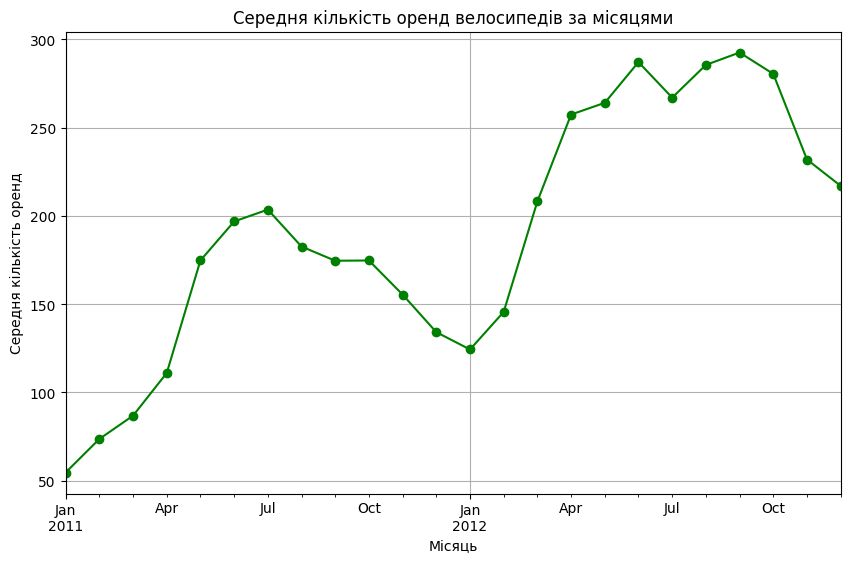

In [5]:
monthly_rent.plot(
    marker="o",
    figsize=(10, 6),
    color="green",
    grid=True,
    xlabel="Місяць",
    ylabel="Середня кількість оренд",
    title="Середня кількість оренд велосипедів за місяцями"
)

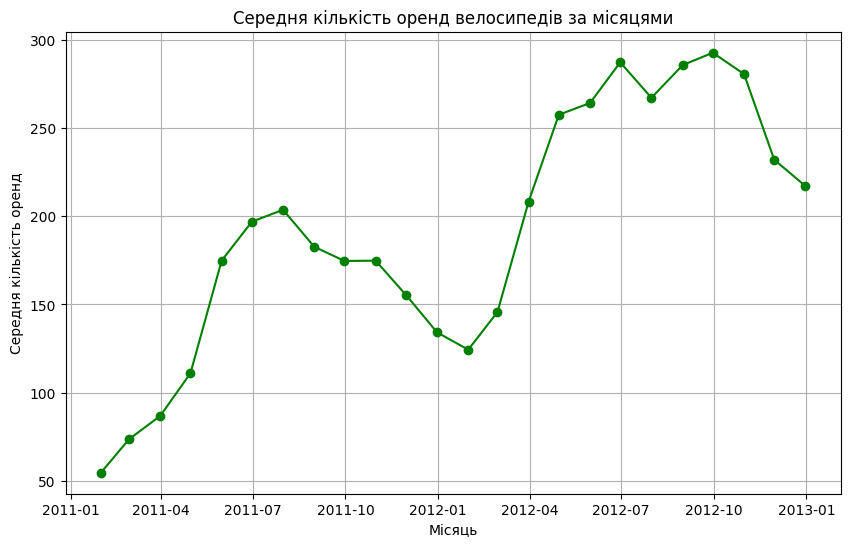

In [8]:
plt.figure(figsize=(10, 6))
plt.plot(monthly_rent.index, monthly_rent, marker="o", color="green")
plt.title("Середня кількість оренд велосипедів за місяцями")
plt.xlabel("Місяць")
plt.ylabel("Середня кількість оренд")
plt.grid(True);


Обидва графіки показують однакові дані та виглядають майже однаково. У Matplotlib для побудови й оформлення графіка потрібно використовувати більше окремих команд, але він дає більше можливостей для налаштування. Мені зручніше будувати графік через Pandas, оскільки це простіше та потребує менше коду.

## Завдання 2: Робота зі списками та numpy

**Завдання:**
Вам задані 3 списки:
1. Номер дня тижня.
2. Продажі в тиждень 1.
3. Продажі в тиждень 2.

Створіть графік, на якому лінійними графіками різних кольорів накладено продажі за обидва тижні.

Обовʼязково додайте назву графіку, підписи вісям ОХ, ОУ, назви кожного з рядів даних, легенду.

**Дайте відповіді на питання**
1. Судячи з графіку, в який тиждень проодажі були стабільніше?
2. Чи можете ви підкріпити свій висновок обчисленнями? Якими саме? Можна (але не обовʼязково) навести ці обчислення.

In [9]:
# Дані у вигляді списків
days = [1, 2, 3, 4, 5, 6, 7] # 1 - це понеділок
sales_week1 = [1349,1562,1600,1606,1510,959,822]  # Продажі за тиждень1
sales_week2 = [1321,1263,1162,1406,1421,1248,1204]  # Продажі за тиждень1

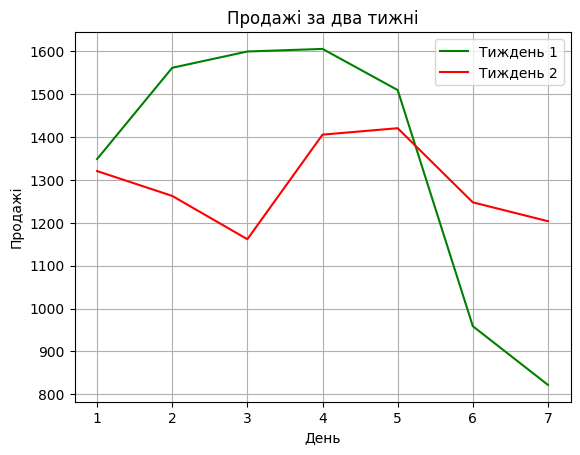

In [10]:
plt.plot(days, sales_week1, color="green", label="Тиждень 1")
plt.plot(days, sales_week2, color="red", label="Тиждень 2")
plt.legend()
plt.title("Продажі за два тижні")
plt.xlabel("День")
plt.ylabel("Продажі")
plt.grid(True)

In [12]:
print(np.std(sales_week1))
print(np.std(sales_week2))

299.99857142517004
90.9060964256355


Продажі у другий тиждень були стабільнішими. Це можна підтвердити стандартним відхиленням: для першого тижня воно становить приблизно 300, а для другого — 91. Менше стандартне відхилення у другому тижні означає, що продажі менше відхилялися від середнього значення.

## Завдання 3: Subplot - 2x2 сітка графіків

**Завдання:**
Створіть сітку 2x2 з чотирма різними графіками, використовуючи `plt.subplot()`:
1. Лінійний графік середньої температури помісячно.
2. Стовпчикова діаграма середньої годинної кількості оренд за кварталами.
3. Гістограма вологості за всіма погодинними вимірами.
4. Scatter plot температури vs кількості оренд.

Кожен підграфік має містити всі необхідні підписи. Дашборд має містити назву.

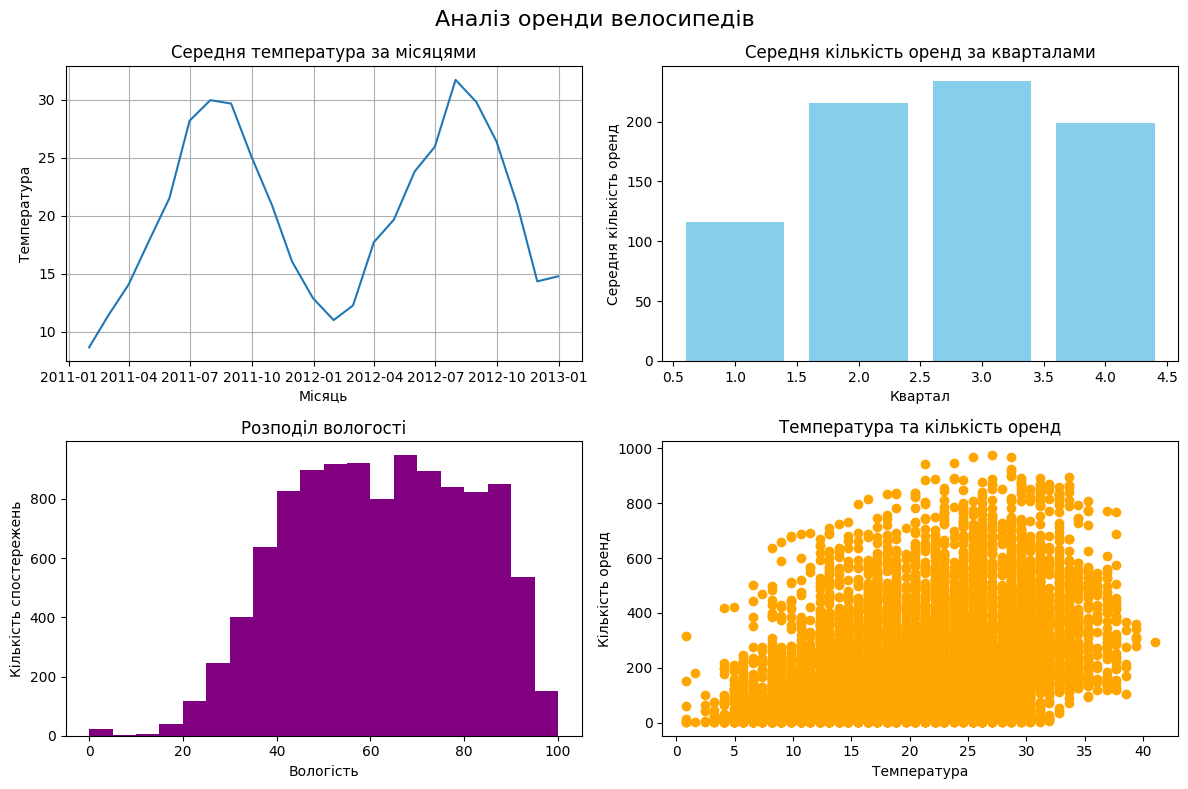

In [18]:
monthly_temp = df["temp"].resample("ME").mean()
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(monthly_temp.index, monthly_temp)
plt.title("Середня температура за місяцями")
plt.xlabel("Місяць")
plt.ylabel("Температура")
plt.grid(True)

quarter_rent = df.groupby("season")["count"].mean()

plt.subplot(2, 2, 2)
plt.bar(quarter_rent.index, quarter_rent, color="skyblue")
plt.title("Середня кількість оренд за кварталами")
plt.xlabel("Квартал")
plt.ylabel("Середня кількість оренд")

plt.subplot(2, 2, 3)
plt.hist(df["humidity"], bins=20, color="purple")
plt.title("Розподіл вологості")
plt.xlabel("Вологість")
plt.ylabel("Кількість спостережень")

plt.subplot(2, 2, 4)

plt.scatter(df["temp"], df["count"], color="orange")

plt.title("Температура та кількість оренд")
plt.xlabel("Температура")
plt.ylabel("Кількість оренд")

plt.suptitle("Аналіз оренди велосипедів", fontsize=16)
plt.tight_layout()

## Завдання 4: Subplots - об'єктно-орієнтований підхід

**Завдання:**
Створіть той самий набір графіків, але використовуючи `fig, ax = plt.subplots()`.

**Дайте відповідь на питання своїми словами**
- Чим відрізняється підхід побудови кількох графіків на одній фігурі з `plt.subplots()` від `plt.subplot()`?

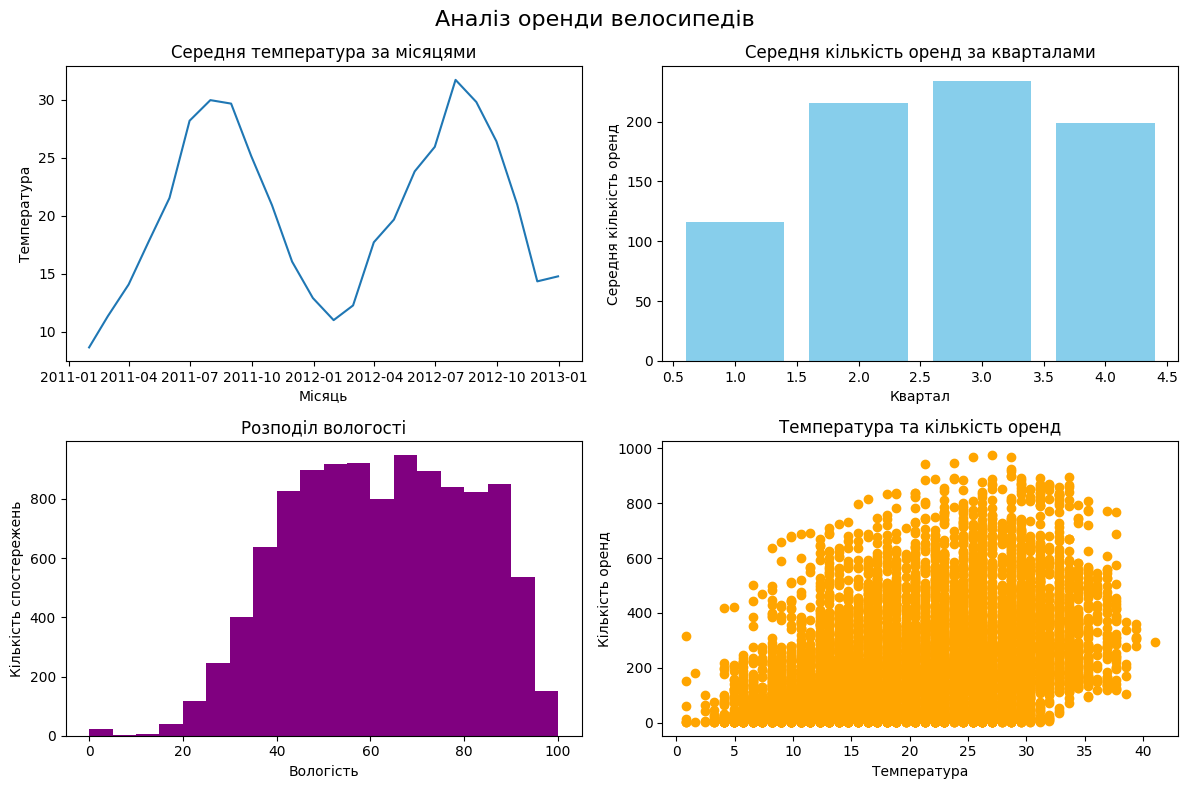

In [25]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
ax[0, 0].plot(monthly_temp.index, monthly_temp)

ax[0, 0].set_title("Середня температура за місяцями")
ax[0, 0].set_xlabel("Місяць")
ax[0, 0].set_ylabel("Температура")

ax[0, 1].bar(quarter_rent.index, quarter_rent, color="skyblue")

ax[0, 1].set_title("Середня кількість оренд за кварталами")
ax[0, 1].set_xlabel("Квартал")
ax[0, 1].set_ylabel("Середня кількість оренд")

ax[1, 0].hist(df["humidity"], bins=20, color="purple")

ax[1, 0].set_title("Розподіл вологості")
ax[1, 0].set_xlabel("Вологість")
ax[1, 0].set_ylabel("Кількість спостережень")

ax[1, 1].scatter(df["temp"], df["count"], color="orange")

ax[1, 1].set_title("Температура та кількість оренд")
ax[1, 1].set_xlabel("Температура")
ax[1, 1].set_ylabel("Кількість оренд")

fig.suptitle("Аналіз оренди велосипедів", fontsize=16)
fig.tight_layout()

Обидва способи дозволяють створювати декілька графіків на одній фігурі. plt.subplot() дає змогу послідовно вибирати місце для кожного графіка, а plt.subplots() одразу створює сітку та дозволяє керувати кожним графіком через ax. Особисто мені plt.subplot() здається простішим і зрозумілішим.

## (Опціонально) Завдання 5: Тонкі налаштування форматування графіка

**Завдання:**
Подібно до прикладу, наведеного в лекції, створіть професійно оформлений графік помісячної динаміки оренди з максимальною кількістю деталей та налаштувань. Ваш графік має включати:

**Обов'язкові елементи:**
1. **Три лінії:** середнє, максимум, мінімум за місяцями
2. **Різні стилі ліній:** суцільна, пунктирна, крапкова + різні маркери
3. **Заливка області** між мінімумом та максимумом
4. **Дві анотації:** для найвищого та найнижчого середнього значення
5. **Горизонтальна лінія** середнього за весь рік
6. **Двошарова сітка:** основна та допоміжна
7. **Стилізована легенда** з тінню
8. **Текстовий блок** зі статистикою в кутку графіка
9. **Професійне оформлення:** заголовки, підписи осей з жирним шрифтом

**Результат:** Графік повинен виглядати як готова ілюстрація для бізнес-звіту або наукової публікації.

Приклад очікуваного результату.
![](https://drive.google.com/uc?id=1YoJByivzlqncEF2zbWu3EhGSZ7XRme8T)


**Питання для інтерпретації:**
1. Яка перевага додавання анотацій на графік?
2. Для чого використовується fill_between()?
3. Як текстовий блок допомагає в інтерпретації даних?

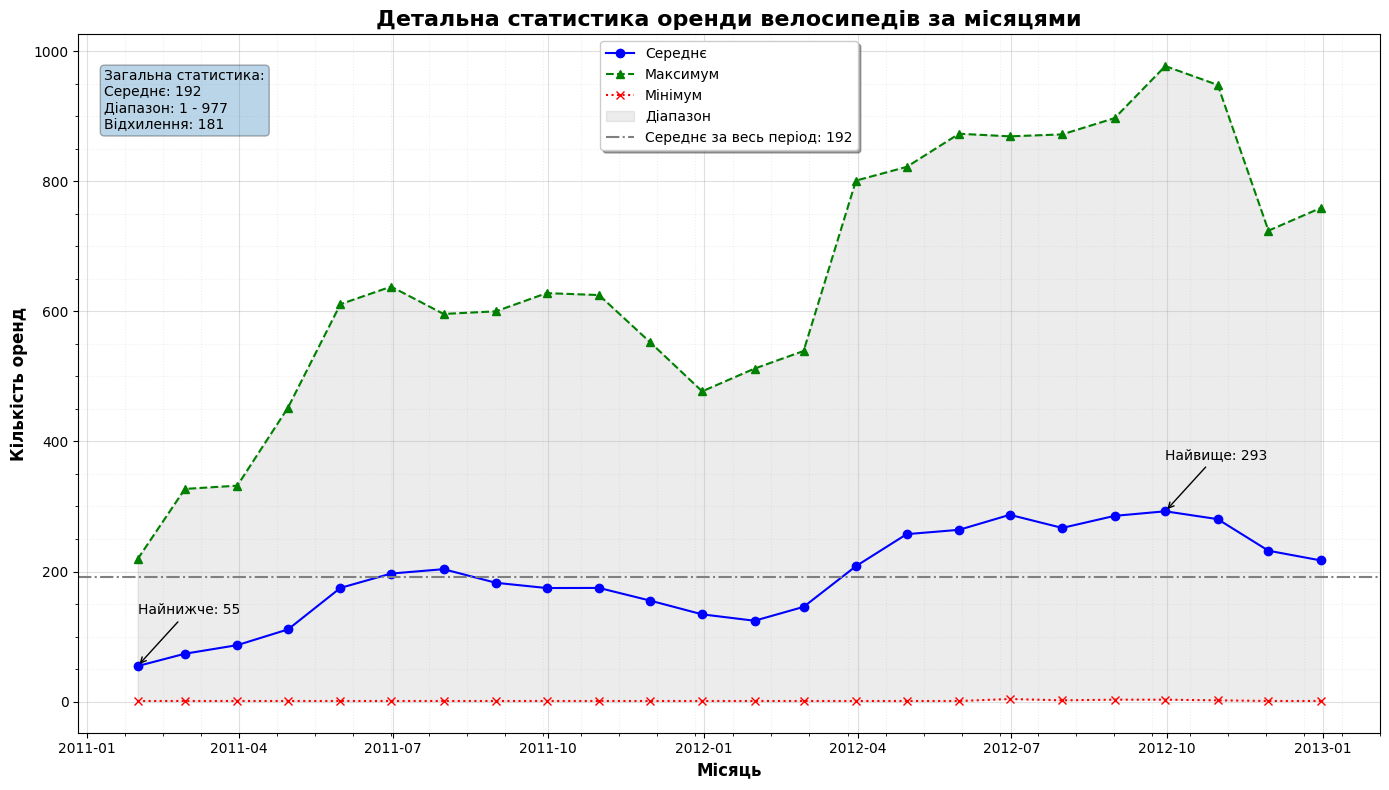

In [40]:
#Помісячна статистика
monthly_stats = df["count"].resample("ME").agg(["mean", "max", "min"])

#Середнє значення за весь період
overall_mean = df["count"].mean()

#Місяці з найбільшим і найменшим середнім значенням
max_month = monthly_stats["mean"].idxmax()
min_month = monthly_stats["mean"].idxmin()
max_value = monthly_stats["mean"].max()
min_value = monthly_stats["mean"].min()

#Створюємо фігуру
plt.figure(figsize=(14, 8))

#1–2. Три лінії: середнє, максимум, мінімум
plt.plot( monthly_stats.index,
         monthly_stats["mean"],
          color="blue",
          linestyle="-",
          marker="o",
          label="Середнє" )

plt.plot( monthly_stats.index,
         monthly_stats["max"],
          color="green",
          linestyle="--",
          marker="^",
          label="Максимум" )
plt.plot( monthly_stats.index,
         monthly_stats["min"],
          color="red",
          linestyle=":",
          marker="x",
          label="Мінімум" )

#3. Заливка між мінімумом і максимумом
plt.fill_between(
    monthly_stats.index,
    monthly_stats["min"],
    monthly_stats["max"],
    alpha=0.15,
    color="gray",
    label="Діапазон" )

#4. Анотація максимального середнього значення
plt.annotate(
     f"Найвище: {max_value:.0f}",
     xy=(max_month, max_value),
     xytext=(max_month, max_value + 80),
     arrowprops=dict(arrowstyle="->") )
#Анотація мінімального середнього значення
plt.annotate( f"Найнижче: {min_value:.0f}",
             xy=(min_month, min_value),
              xytext=(min_month, min_value + 80),
              arrowprops=dict(arrowstyle="->") )


#5. Горизонтальна лінія загального середнього
plt.axhline( y=overall_mean,
          color="gray",
             linestyle="-.",
             label=f"Середнє за весь період: {overall_mean:.0f}" )

#6. Основна та допоміжна сітка
plt.grid(True, which="major",
         linestyle="-",
         alpha=0.4)
plt.minorticks_on()
plt.grid(True, which="minor", linestyle=":", alpha=0.2)

#7. Легенда з тінню
plt.legend(shadow=True)

#8. Текстовий блок зі статистикою
stats_text = (
    f"Загальна статистика:\n"
    f"Середнє: {overall_mean:.0f}\n"
    f"Діапазон: {df['count'].min()} - {df['count'].max()}\n"
    f"Відхилення: {df['count'].std():.0f}" )
plt.text(
    0.02,
    0.95,
    stats_text,
    transform=plt.gca().transAxes,
    verticalalignment="top",
    bbox=dict(boxstyle="round", alpha=0.3)
     )

#9. Професійне оформлення
plt.title(
     "Детальна статистика оренди велосипедів за місяцями",
     fontsize=16,
     fontweight="bold" )

plt.xlabel(
    "Місяць",
    fontsize=12,
    fontweight="bold" )

plt.ylabel(
    "Кількість оренд",
    fontsize=12,
    fontweight="bold" )

plt.tight_layout()
plt.show()












1.Анотації допомагають виділити важливі точки на графіку, наприклад максимальне та мінімальне значення, і роблять графік зрозумілішим.
2.ill_between() використовується для зафарбовування області між двома лініями на графіку. У нашому випадку — між мінімальною та максимальною кількістю оренд.
3.Текстовий блок дозволяє одразу показати основні статистичні показники на графіку, тому користувачеві легше зрозуміти дані без додаткових розрахунків.


